In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
df = pd.read_csv("https://raw.githubusercontent.com/sriram187-07/Machine-learning-Lab/refs/heads/main/Mall_Customers.csv")

# Display first 5 rows
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [5]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

# Elbow Method
inertia = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X)
    inertia.append(model.inertia_)

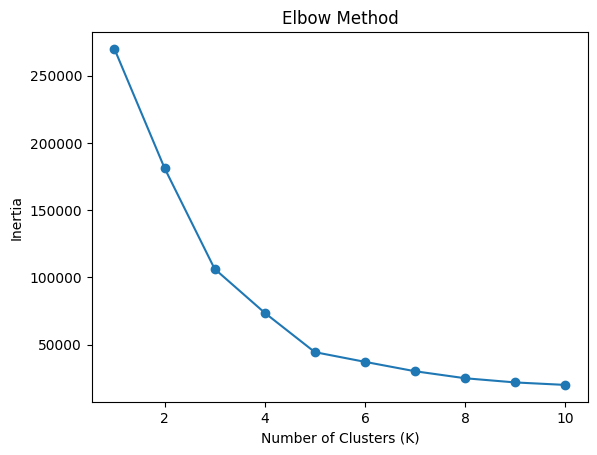

In [7]:
plt.plot(range(1, 11), inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [8]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

# Train the model
kmeans.fit(X)

,n_clusters,5
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [ ]:
df["Cluster"] = kmeans.labels_

# Print cluster centers
print("\nCluster Centers:")
print(kmeans.cluster_centers_)

# Print customer segmentation
print("\nCustomer Segmentation:")
print(df[[
    "CustomerID",
    "Annual Income (k$)",
    "Spending Score (1-100)",
    "Cluster"
]])

# Visualize clusters
plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=df["Cluster"]
)

# Plot cluster centers
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation Using K-Means")

plt.show()